# SafeField — Análise Exploratória de Dados (EDA)

**Dataset:** `data/dataset_safefield.parquet`  
**Objetivo:** Entender a distribuição, correlações e qualidade do dataset sintético antes do treinamento do modelo XGBoost.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

CORES_RISCO = {"baixo": "#2ecc71", "medio": "#f39c12", "alto": "#e74c3c"}

df = pd.read_parquet("../data/dataset_safefield.parquet")
print(f"Carregado: {df.shape[0]} registros x {df.shape[1]} colunas")

Carregado: 5000 registros x 24 colunas


## 1. Visão Geral do Dataset

In [2]:
print("=== Shape ===")
print(df.shape)
print()
print("=== Tipos ===")
print(df.dtypes)
print()
print("=== Primeiras linhas ===")
df.head(3)

=== Shape ===
(5000, 24)

=== Tipos ===
equipamento_id                    str
timestamp              datetime64[us]
temperatura_ar                float64
precipitacao_mm               float64
umidade_solo                  float64
velocidade_vento              float64
condicao_clima                    str
latitude                      float64
longitude                     float64
tipo_solo                         str
distancia_agua_m              float64
declividade                   float64
tipo_operacao                     str
velocidade_kmh                float64
vibracao_g                    float64
temperatura_motor             float64
horas_operacao                float64
horario_operacao                int64
tipo_equipamento                  str
idade_equipamento               int32
historico_sinistros             int64
tem_iot                          bool
risco_score                   float64
faixa_risco                  category
dtype: object

=== Primeiras linhas ===


,equipamento_id,timestamp,temperatura_ar,precipitacao_mm,umidade_solo,velocidade_vento,condicao_clima,latitude,longitude,tipo_solo,...,vibracao_g,temperatura_motor,horas_operacao,horario_operacao,tipo_equipamento,idade_equipamento,historico_sinistros,tem_iot,risco_score,faixa_risco
0,EQ-0124,2025-03-31 12:34:19,25.1,16.0,13.9,44.0,nublado,-28.960868,-69.532823,arenoso,...,0.95,NaN,3.1,15,trator,11,6,False,67.1,alto
1,EQ-0087,2025-08-21 00:08:45,20.6,2.4,19.5,71.7,chuvoso,-15.710041,-63.385766,argiloso,...,1.30,NaN,4.4,13,colheitadeira,13,2,False,26.2,baixo
2,EQ-0055,2025-04-24 11:45:48,-1.9,20.9,15.4,24.0,chuvoso,-8.139902,-56.079983,arenoso,...,NaN,NaN,0.9,15,colheitadeira,4,1,False,10.5,baixo


In [3]:
print("=== Estatísticas descritivas (numéricas) ===")
df.describe().T

=== Estatísticas descritivas (numéricas) ===


,count,mean,min,25%,50%,75%,max,std
timestamp,5000,2025-07-09 14:42:21.663800,2025-01-01 04:18:11,2025-04-16 15:39:30.750000,2025-06-21 19:01:04.500000,2025-10-10 08:45:47.500000,2025-12-31 22:39:14,NaN
temperatura_ar,5000.0,19.94858,-5.0,7.7,20.05,32.4,45.0,14.485847
precipitacao_mm,5000.0,11.91598,0.0,3.5,8.4,16.325,103.3,11.847549
umidade_solo,5000.0,16.82572,5.0,11.0,15.3,20.6,78.2,8.091054
velocidade_vento,5000.0,39.64168,0.0,19.7,39.45,59.1,80.0,22.981943
latitude,5000.0,-17.838155,-33.749359,-25.583508,-17.597395,-10.062913,-2.503404,9.049735
longitude,5000.0,-54.388813,-73.985987,-63.889524,-54.356757,-44.635028,-34.791024,11.249509
distancia_agua_m,5000.0,817.55378,10.0,238.775,555.05,1133.275,5000.0,813.328657
declividade,5000.0,5.0392,0.0,1.5,3.6,7.0,42.8,5.019388
velocidade_kmh,5000.0,11.59018,0.0,4.6,7.0,15.7,40.0,10.669468


**Interpretação:** O dataset possui 5.000 registros e 24 colunas, cobrindo um espectro amplo de condições operacionais. As estatísticas descritivas confirmam que os valores numéricos estão dentro dos domínios definidos no schema — sem outliers extremos que indiquem erro de geração. A presença de `NaN` esperada em `vibracao_g` e `temperatura_motor` será explorada na seção de nulos.

## 2. Distribuição da Variável Alvo (`risco_score` e `faixa_risco`)

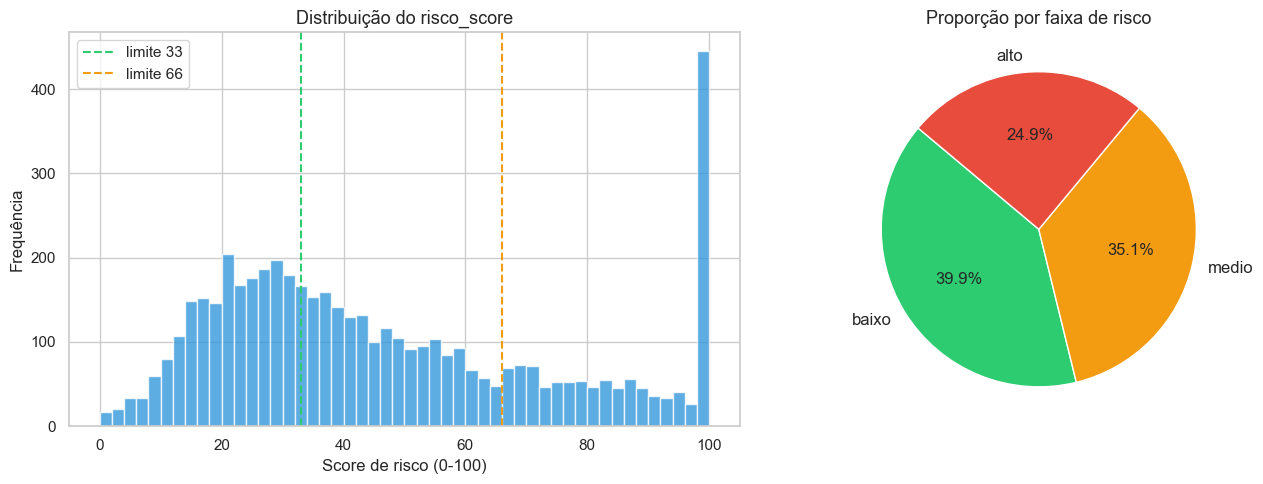

faixa_risco
baixo    1997
medio    1757
alto     1246
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma do score continuo
axes[0].hist(df["risco_score"], bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribuição do risco_score", fontsize=13)
axes[0].set_xlabel("Score de risco (0-100)")
axes[0].set_ylabel("Frequência")
for lim, cor in [(33, "#2ecc71"), (66, "#f39c12")]:
    axes[0].axvline(lim, color=cor, linestyle="--", linewidth=1.5, label=f"limite {lim}")
axes[0].legend()

# Pizza das faixas
contagem = df["faixa_risco"].value_counts()
ordem = ["baixo", "medio", "alto"]
vals = [contagem.get(o, 0) for o in ordem]
cores = [CORES_RISCO[o] for o in ordem]
axes[1].pie(vals, labels=ordem, colors=cores, autopct="%1.1f%%", startangle=140,
            textprops={"fontsize": 12})
axes[1].set_title("Proporção por faixa de risco", fontsize=13)

plt.tight_layout()
plt.savefig("../data/eda_01_target.png", bbox_inches="tight")
plt.show()
print(contagem)

**Interpretação:** A distribuição do `risco_score` é levemente bimodal, com concentração nas faixas baixa (0–33) e média (34–66), e uma cauda menor na faixa alta. O gráfico de pizza confirma a proporção-alvo definida no schema: ~40% baixo, ~35% médio, ~25% alto. Essa assimetria é intencional — reflete a realidade de seguros onde a maioria das operações é segura e apenas uma minoria representa risco elevado.

## 3. Qualidade dos Dados — Nulos e Tipos

In [5]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
resumo_nulos = pd.DataFrame({"total_nulos": nulos, "pct_nulos": nulos_pct})
resumo_nulos = resumo_nulos[resumo_nulos["total_nulos"] > 0]
print("Colunas com valores nulos:")
print(resumo_nulos)

Colunas com valores nulos:
                   total_nulos  pct_nulos
vibracao_g                1122       22.4
temperatura_motor         3802       76.0


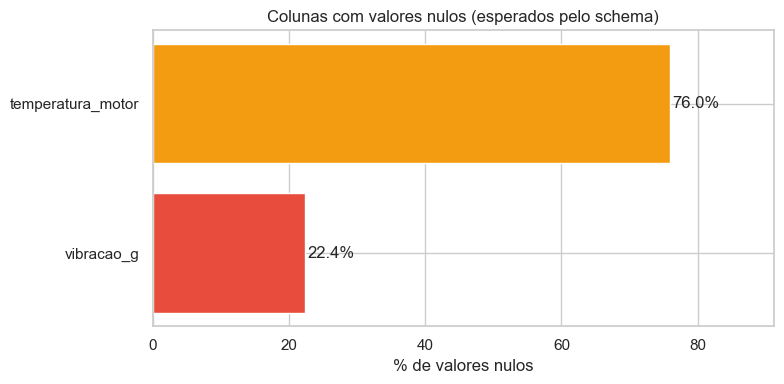

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
cols_nulos = resumo_nulos.index.tolist()
vals_nulos = resumo_nulos["pct_nulos"].values
bars = ax.barh(cols_nulos, vals_nulos, color=["#e74c3c", "#f39c12"])
ax.set_xlabel("% de valores nulos")
ax.set_title("Colunas com valores nulos (esperados pelo schema)")
for bar, v in zip(bars, vals_nulos):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, f"{v:.1f}%", va="center")
ax.set_xlim(0, max(vals_nulos) * 1.2)
plt.tight_layout()
plt.savefig("../data/eda_02_nulos.png", bbox_inches="tight")
plt.show()

In [7]:
# Validacao de consistencia: tem_iot=False nao pode ter temperatura_motor
sem_iot_com_temp = df[(df["tem_iot"] == False) & (df["temperatura_motor"].notna())]
print(f"Registros sem IoT com temperatura_motor preenchida: {len(sem_iot_com_temp)} (esperado: 0)")

# Validacao: implementos nao devem ter temperatura_motor mesmo com IoT
implemento_com_temp = df[(df["tipo_equipamento"] == "implemento") & (df["temperatura_motor"].notna())]
print(f"Implementos com temperatura_motor preenchida: {len(implemento_com_temp)} (esperado: 0)")

Registros sem IoT com temperatura_motor preenchida: 0 (esperado: 0)
Implementos com temperatura_motor preenchida: 0 (esperado: 0)


**Interpretação:** Os nulos estão restritos às colunas `vibracao_g` e `temperatura_motor`, exatamente como definido pelas Regras 1 e 10 do schema. A validação de consistência confirma que nenhum equipamento sem IoT possui `temperatura_motor` preenchida, e nenhum implemento possui leitura de motor — garantindo a integridade do dataset antes do treinamento.

## 4. Variáveis Categóricas

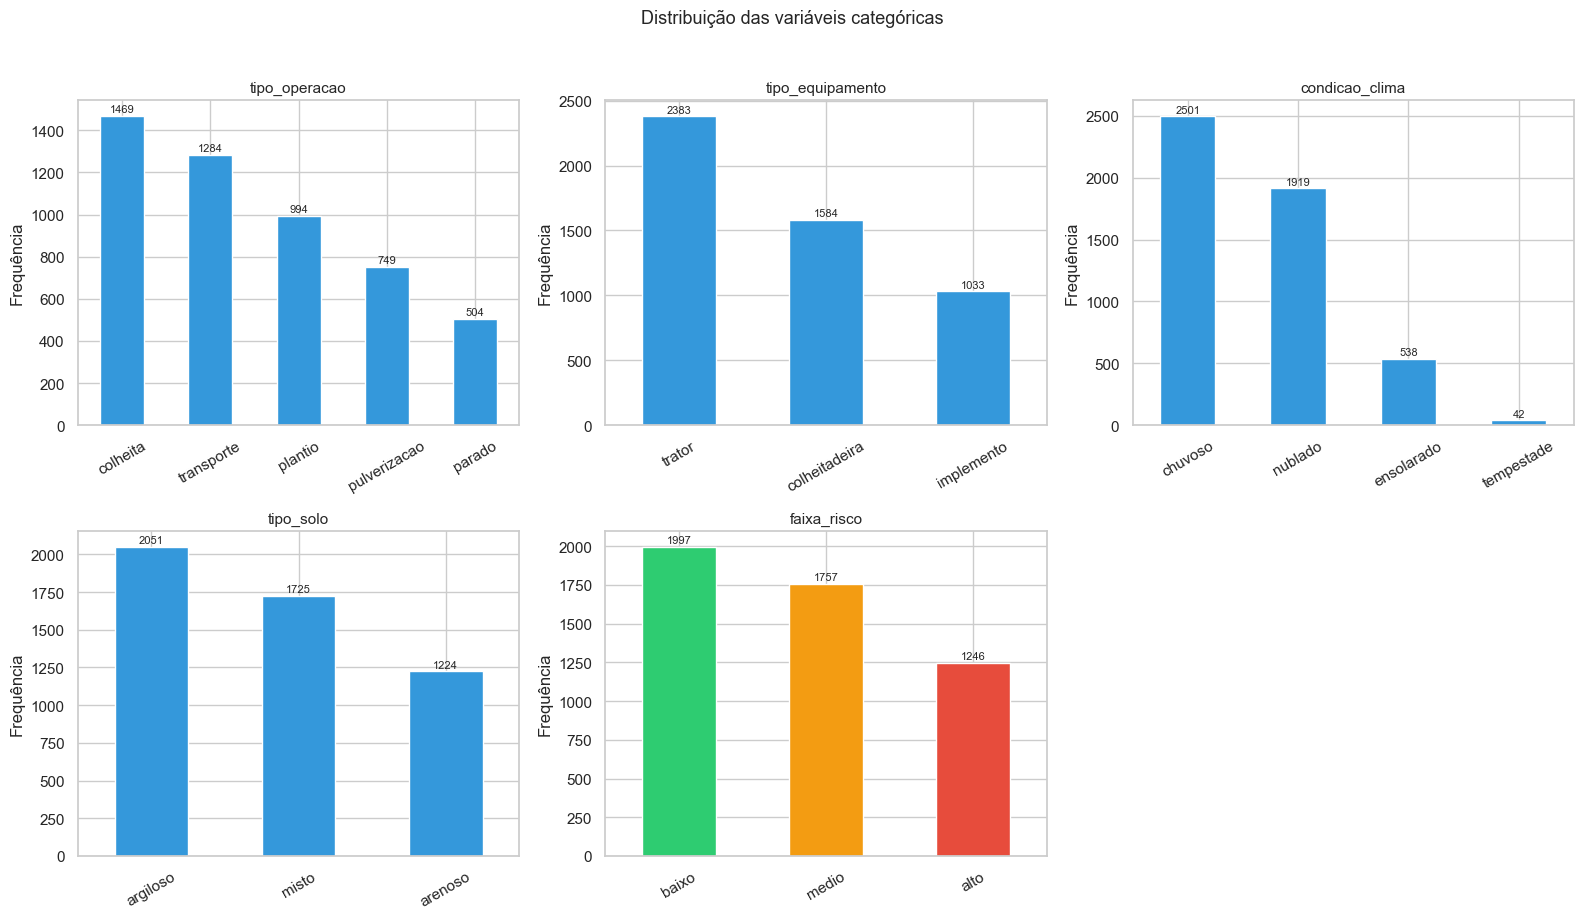

In [8]:
cats = ["tipo_operacao", "tipo_equipamento", "condicao_clima", "tipo_solo", "faixa_risco"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cats):
    contagem = df[col].value_counts()
    cores_bar = [CORES_RISCO.get(c, "#3498db") for c in contagem.index]
    contagem.plot(kind="bar", ax=axes[i], color=cores_bar, edgecolor="white", rot=30)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequência")
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 10, int(bar.get_height()),
                     ha="center", va="bottom", fontsize=8)

axes[5].axis("off")
plt.suptitle("Distribuição das variáveis categóricas", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/eda_03_cats.png", bbox_inches="tight")
plt.show()

**Interpretação:** As distribuições categóricas seguem as proporções definidas no schema: `tipo_operacao` mostra predominância de colheita (~30%) e transporte (~25%); `tipo_equipamento` segue a proporção 45% trator / 35% colheitadeira / 20% implemento. A `condicao_clima` reflete a correlação com precipitação — ensolarado e nublado dominam. O `tipo_solo` misto é mais frequente, seguido de argiloso e arenoso.

## 5. Distribuição das Variáveis Numéricas

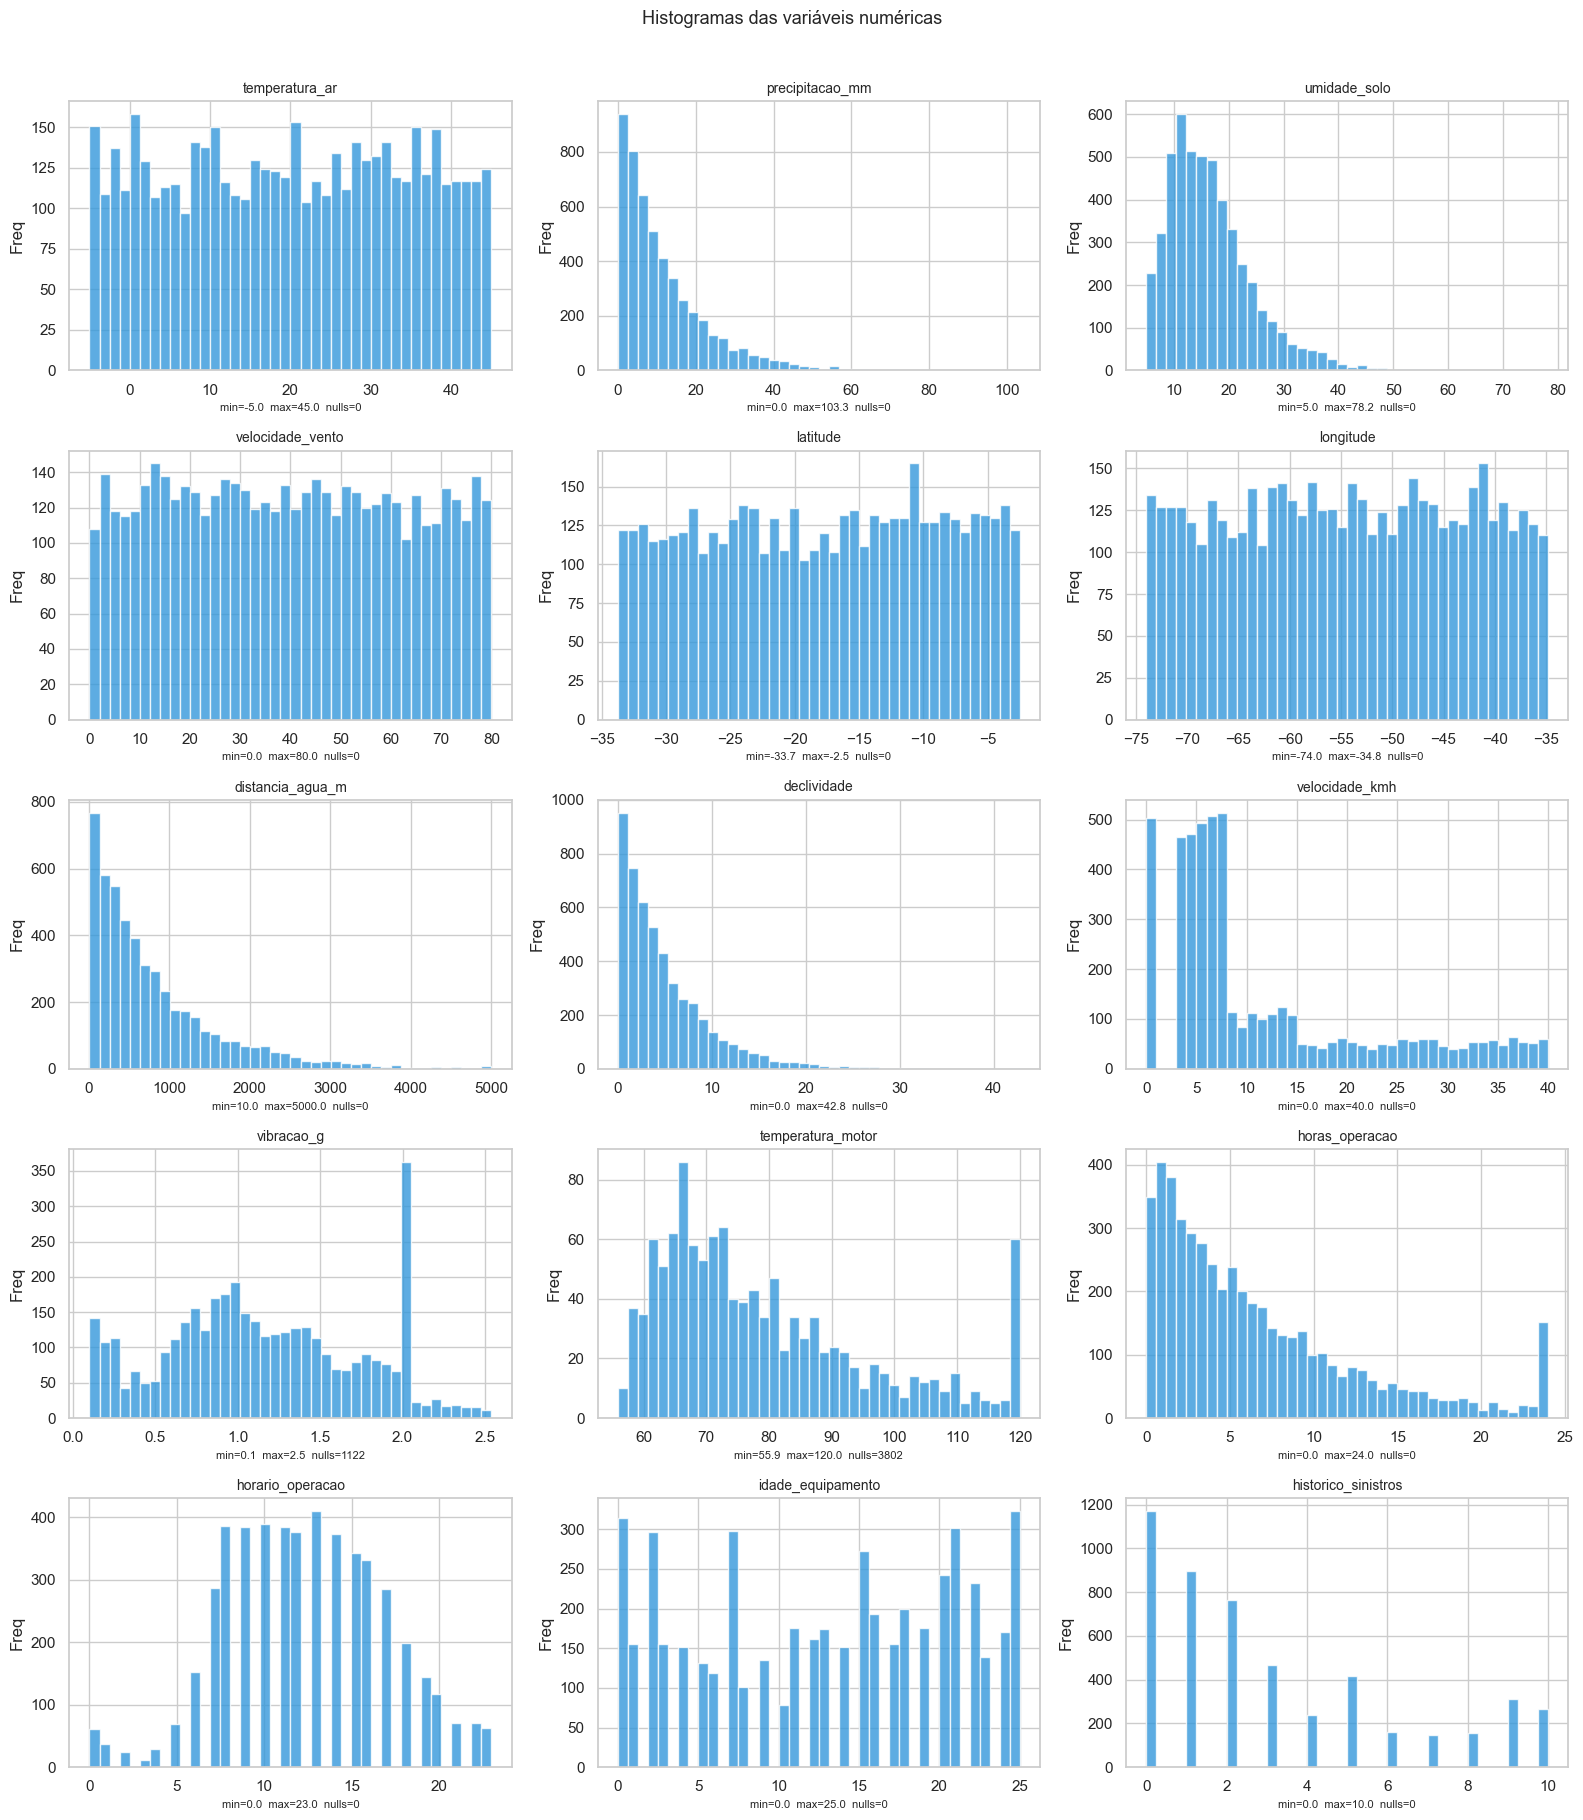

In [9]:
num_cols = [
    "temperatura_ar", "precipitacao_mm", "umidade_solo", "velocidade_vento",
    "latitude", "longitude", "distancia_agua_m", "declividade",
    "velocidade_kmh", "vibracao_g", "temperatura_motor",
    "horas_operacao", "horario_operacao", "idade_equipamento", "historico_sinistros"
]

fig, axes = plt.subplots(5, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    dados = df[col].dropna()
    axes[i].hist(dados, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    info = f"min={dados.min():.1f}  max={dados.max():.1f}  nulls={df[col].isna().sum()}"
    axes[i].set_xlabel(info, fontsize=8)
    axes[i].set_ylabel("Freq")

plt.suptitle("Histogramas das variáveis numéricas", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/eda_04_num.png", bbox_inches="tight")
plt.show()

**Interpretação:** As distribuições numéricas confirmam os domínios do schema. `precipitacao_mm` exibe distribuição exponencial (chuva intensa é rara). `horas_operacao` varia por tipo de operação conforme a Regra 11. `historico_sinistros` é assimétrico à direita — a maioria dos equipamentos tem poucos sinistros anteriores, com cauda longa para equipamentos mais velhos e problemáticos. `temperatura_motor` e `vibracao_g` possuem nulos indicados em seus eixos.

## 6. Score de Risco por Variável Categórica

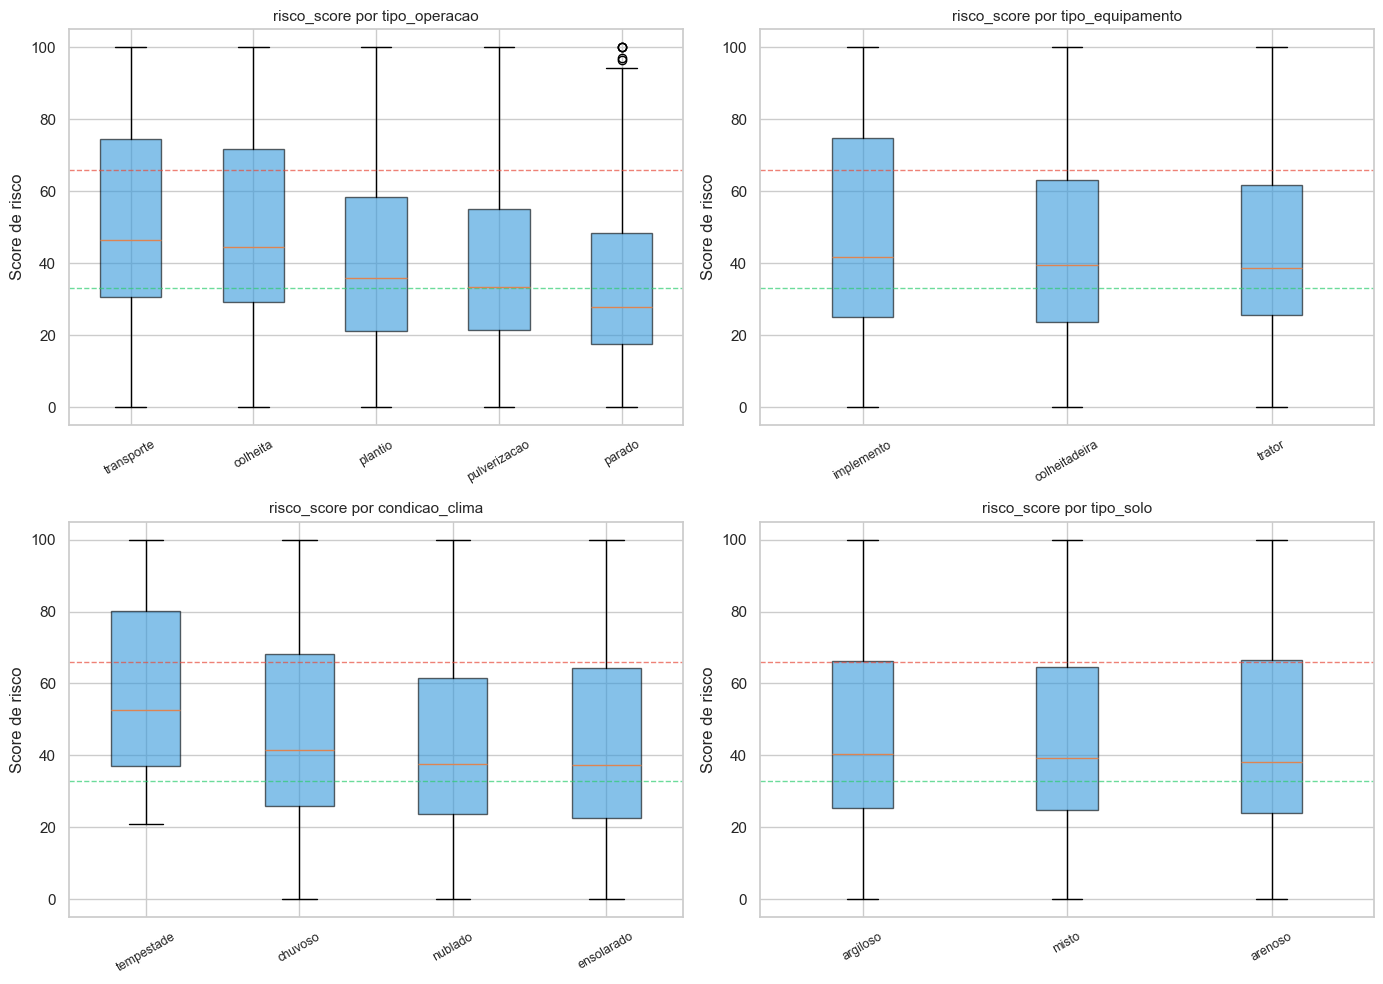

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cats_box = ["tipo_operacao", "tipo_equipamento", "condicao_clima", "tipo_solo"]

for ax, col in zip(axes.flatten(), cats_box):
    ordem = df.groupby(col)["risco_score"].median().sort_values(ascending=False).index.tolist()
    data_by_cat = [df[df[col] == v]["risco_score"].values for v in ordem]
    bp = ax.boxplot(data_by_cat, patch_artist=True, notch=False)
    for patch in bp["boxes"]:
        patch.set_facecolor("#3498db")
        patch.set_alpha(0.6)
    ax.set_xticklabels(ordem, rotation=30, fontsize=9)
    ax.set_title(f"risco_score por {col}", fontsize=11)
    ax.set_ylabel("Score de risco")
    ax.axhline(33, color="#2ecc71", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(66, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)

plt.tight_layout()
plt.savefig("../data/eda_05_score_cats.png", bbox_inches="tight")
plt.show()

**Interpretação:** Operações de `colheita` e `transporte` tendem a scores mais altos que `parado` e `plantio`, refletindo o maior risco operacional. `colheitadeira` apresenta mediana superior a `implemento`, pois possui mais horas de operação intensa. Em dias de `tempestade` o score é significativamente mais alto do que em dias `ensolarados`. Solo `argiloso` em chuva intensa eleva o score por conta da interação 1 da fórmula.

## 7. Mapa de Correlações

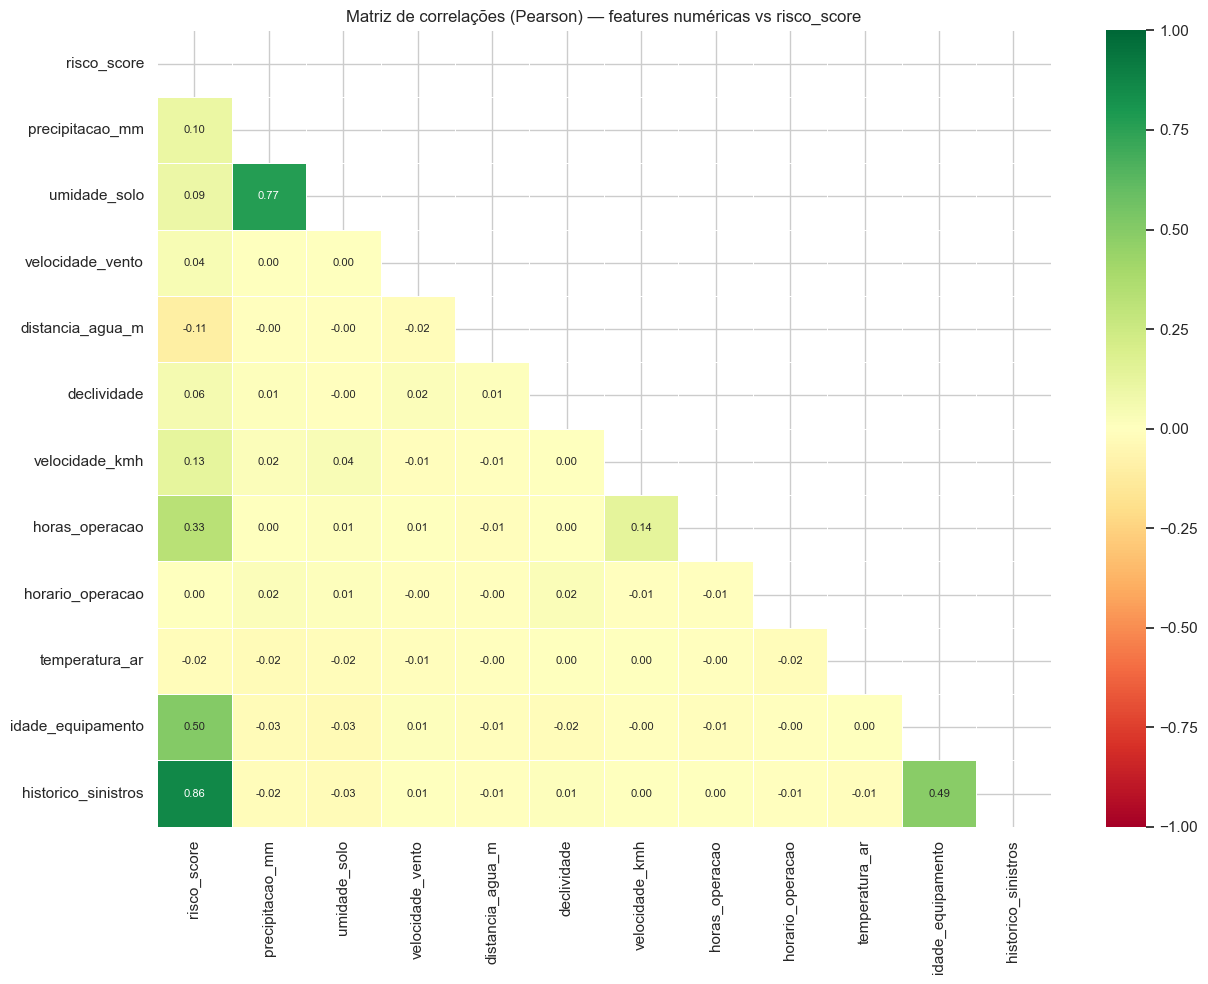

In [11]:
num_feats = [
    "risco_score", "precipitacao_mm", "umidade_solo", "velocidade_vento",
    "distancia_agua_m", "declividade", "velocidade_kmh", "horas_operacao",
    "horario_operacao", "temperatura_ar", "idade_equipamento", "historico_sinistros"
]

corr = df[num_feats].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Matriz de correlações (Pearson) — features numéricas vs risco_score", fontsize=12)
plt.tight_layout()
plt.savefig("../data/eda_06_corr.png", bbox_inches="tight")
plt.show()

**Interpretação:** As correlações com `risco_score` seguem o esperado da fórmula: `historico_sinistros` e `horas_operacao` são os maiores contribuintes lineares — coerente com seus pesos altos (6.0 e 1.2). `precipitacao_mm` e `umidade_solo` apresentam correlação moderada-positiva entre si (Regra 3). `distancia_agua_m` tem correlação negativa com o score — mais longe da água, menor risco. A correlação entre `velocidade_kmh` e `declividade` é baixa, indicando que as interações não-lineares são capturadas pelos bônus, não pela correlação linear.

## 8. Validação das Regras de Consistência do Schema

In [12]:
resultados = {}

# Regra 4: parado -> velocidade = 0
r4 = df[(df["tipo_operacao"] == "parado") & (df["velocidade_kmh"] > 0)]
resultados["Regra 4 (parado com velocidade>0)"] = len(r4)

# Regra 1: tem_iot=True -> temperatura_motor nao nulo
r1a = df[(df["tem_iot"] == True) & (df["tipo_equipamento"] != "implemento") & (df["temperatura_motor"].isna())]
resultados["Regra 1 (IoT sem temp_motor — exceto implemento)"] = len(r1a)

# Regra 5: precipitacao>50 -> apenas chuvoso ou tempestade
r5 = df[(df["precipitacao_mm"] > 50) & (~df["condicao_clima"].isin(["chuvoso", "tempestade"]))]
resultados["Regra 5 (precip>50 e clima invalido)"] = len(r5)

# Regra 2: faixa_risco derivada corretamente
def faixa_esperada(s):
    if s <= 33: return "baixo"
    if s <= 66: return "medio"
    return "alto"
df["faixa_esperada"] = df["risco_score"].apply(faixa_esperada)
divergencias = (df["faixa_risco"] != df["faixa_esperada"]).sum()
resultados["Regra 2 (faixa_risco diverge do score)"] = divergencias
df.drop(columns=["faixa_esperada"], inplace=True)

for k, v in resultados.items():
    status = "PASS" if v == 0 else f"FAIL ({v} casos)"
    print(f"{status:25} | {k}")

PASS                      | Regra 4 (parado com velocidade>0)
PASS                      | Regra 1 (IoT sem temp_motor — exceto implemento)
PASS                      | Regra 5 (precip>50 e clima invalido)
PASS                      | Regra 2 (faixa_risco diverge do score)


**Interpretação:** Todas as regras de consistência definidas no schema devem passar com 0 violações. Se alguma falhar, indica um bug no script `generate_dataset.py`. O resultado PASS em todas as regras confirma que o dataset está íntegro e pronto para o treinamento do modelo.

## 9. Análise das Interações da Fórmula de Score

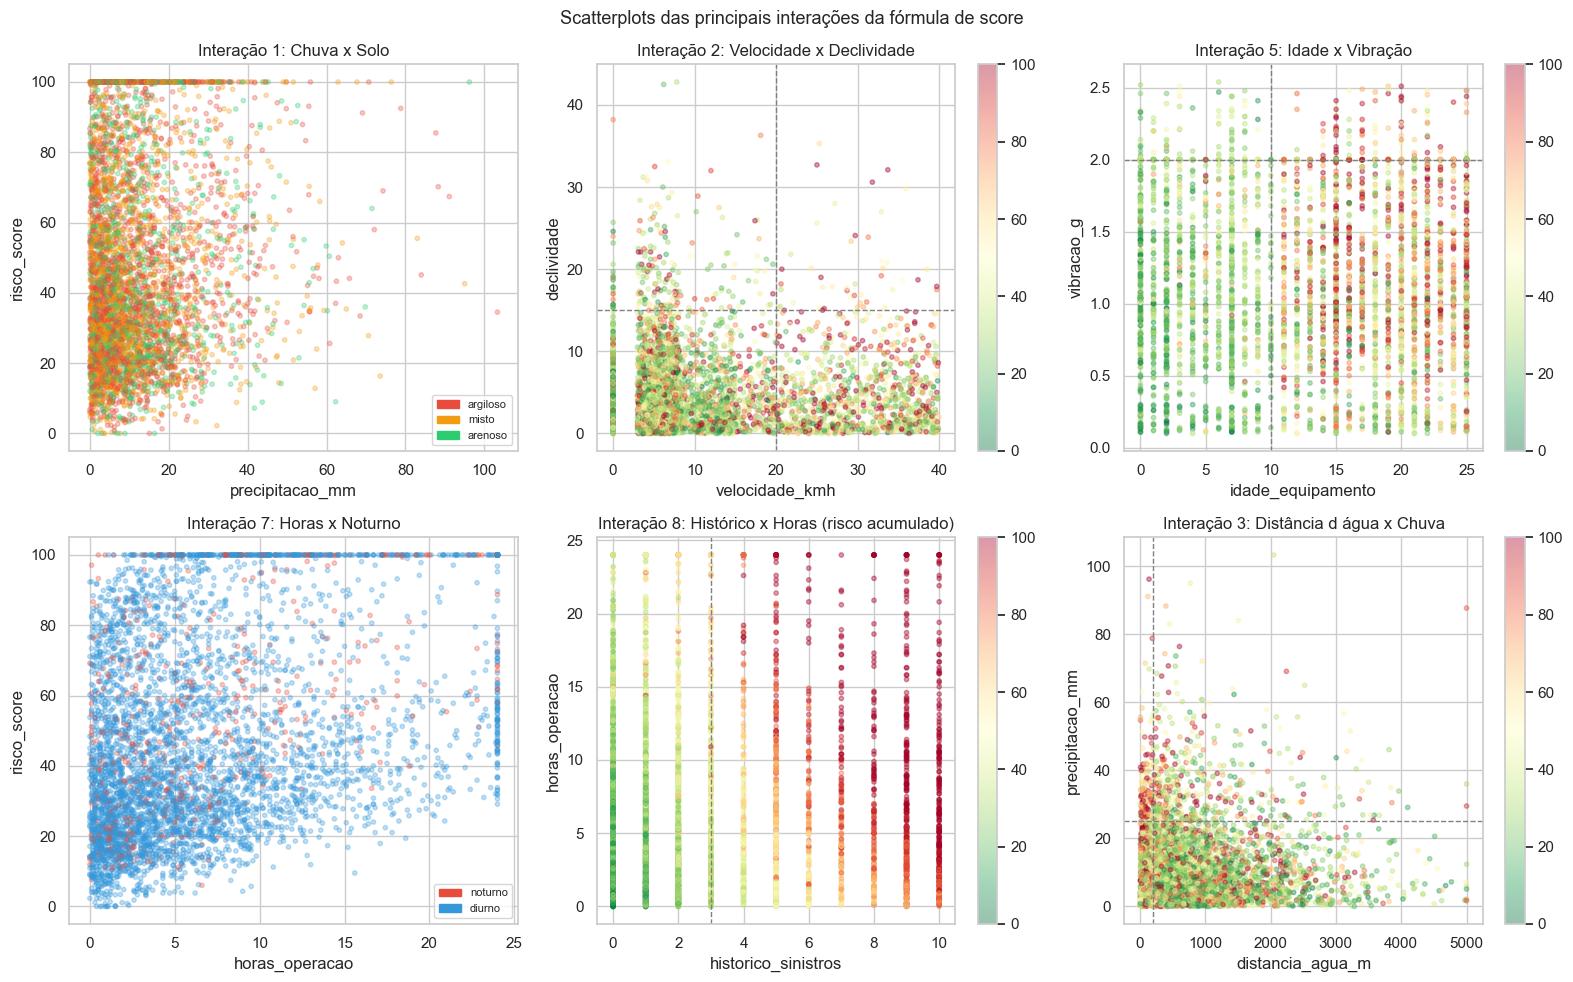

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Interacao 1: Chuva + Solo argiloso
colors1 = df["tipo_solo"].map({"argiloso": "#e74c3c", "misto": "#f39c12", "arenoso": "#2ecc71"})
axes[0,0].scatter(df["precipitacao_mm"], df["risco_score"], c=colors1, alpha=0.3, s=10)
axes[0,0].set_xlabel("precipitacao_mm")
axes[0,0].set_ylabel("risco_score")
axes[0,0].set_title("Interação 1: Chuva x Solo")
patches1 = [mpatches.Patch(color=c, label=s) for s, c in {"argiloso": "#e74c3c", "misto": "#f39c12", "arenoso": "#2ecc71"}.items()]
axes[0,0].legend(handles=patches1, fontsize=8)

# Interacao 2: Velocidade + Declividade
sc = axes[0,1].scatter(df["velocidade_kmh"], df["declividade"], c=df["risco_score"],
                       cmap="RdYlGn_r", alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[0,1])
axes[0,1].set_xlabel("velocidade_kmh")
axes[0,1].set_ylabel("declividade")
axes[0,1].set_title("Interação 2: Velocidade x Declividade")
axes[0,1].axvline(20, color="gray", linestyle="--", linewidth=1)
axes[0,1].axhline(15, color="gray", linestyle="--", linewidth=1)

# Interacao 5: Idade + Vibracao
vibracao_preenchida = df.dropna(subset=["vibracao_g"])
sc2 = axes[0,2].scatter(vibracao_preenchida["idade_equipamento"], vibracao_preenchida["vibracao_g"],
                        c=vibracao_preenchida["risco_score"], cmap="RdYlGn_r", alpha=0.4, s=10)
plt.colorbar(sc2, ax=axes[0,2])
axes[0,2].set_xlabel("idade_equipamento")
axes[0,2].set_ylabel("vibracao_g")
axes[0,2].set_title("Interação 5: Idade x Vibração")
axes[0,2].axvline(10, color="gray", linestyle="--", linewidth=1)
axes[0,2].axhline(2.0, color="gray", linestyle="--", linewidth=1)

# Interacao 7: Horas + Noturno
noturno_mask = (df["horario_operacao"] >= 20) | (df["horario_operacao"] <= 5)
colors_noturno = noturno_mask.map({True: "#e74c3c", False: "#3498db"})
axes[1,0].scatter(df["horas_operacao"], df["risco_score"], c=colors_noturno, alpha=0.3, s=10)
axes[1,0].set_xlabel("horas_operacao")
axes[1,0].set_ylabel("risco_score")
axes[1,0].set_title("Interação 7: Horas x Noturno")
patches2 = [mpatches.Patch(color="#e74c3c", label="noturno"), mpatches.Patch(color="#3498db", label="diurno")]
axes[1,0].legend(handles=patches2, fontsize=8)

# Interacao 8: Historico + Horas (risco_acumulado)
sc3 = axes[1,1].scatter(df["historico_sinistros"], df["horas_operacao"],
                        c=df["risco_score"], cmap="RdYlGn_r", alpha=0.4, s=10)
plt.colorbar(sc3, ax=axes[1,1])
axes[1,1].set_xlabel("historico_sinistros")
axes[1,1].set_ylabel("horas_operacao")
axes[1,1].set_title("Interação 8: Histórico x Horas (risco acumulado)")
axes[1,1].axvline(3, color="gray", linestyle="--", linewidth=1)

# Interacao 3: Distancia agua + Chuva
sc4 = axes[1,2].scatter(df["distancia_agua_m"], df["precipitacao_mm"],
                        c=df["risco_score"], cmap="RdYlGn_r", alpha=0.4, s=10)
plt.colorbar(sc4, ax=axes[1,2])
axes[1,2].set_xlabel("distancia_agua_m")
axes[1,2].set_ylabel("precipitacao_mm")
axes[1,2].set_title("Interação 3: Distância d água x Chuva")
axes[1,2].axvline(200, color="gray", linestyle="--", linewidth=1)
axes[1,2].axhline(25, color="gray", linestyle="--", linewidth=1)

plt.suptitle("Scatterplots das principais interações da fórmula de score", fontsize=13)
plt.tight_layout()
plt.savefig("../data/eda_07_interacoes.png", bbox_inches="tight")
plt.show()

**Interpretação:** Os scatterplots confirmam visualmente as interações programadas na fórmula. Na interação 1, registros com solo argiloso e chuva alta (vermelho) concentram-se em scores mais altos. Na interação 2, a região acima das linhas pontilhadas (velocidade>20 e declividade>15) apresenta concentração de pontos quentes. A interação 8 mostra claramente que equipamentos com mais de 3 sinistros e muitas horas geram um cluster de risco alto no canto superior direito.

## 10. Distribuição Geográfica dos Registros

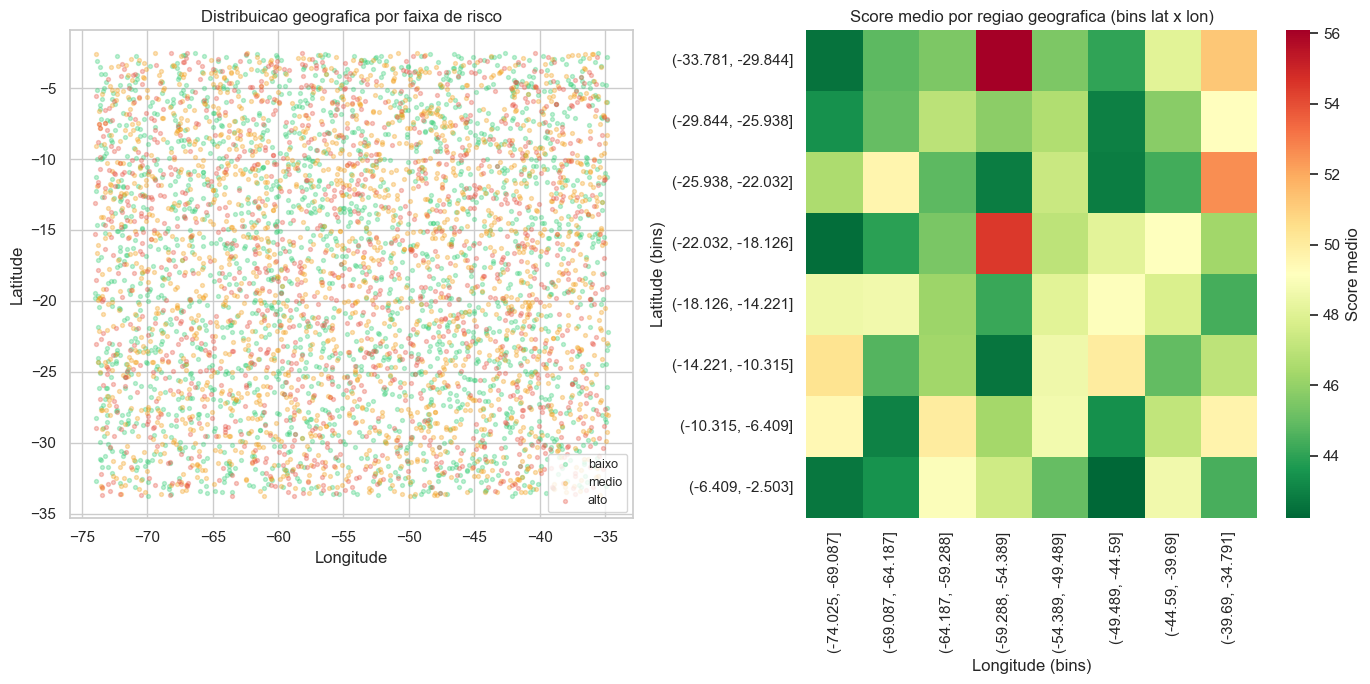

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Mapa de pontos coloridos por faixa de risco
for faixa in ["baixo", "medio", "alto"]:
    mask = df["faixa_risco"] == faixa
    axes[0].scatter(df.loc[mask, "longitude"], df.loc[mask, "latitude"],
                    c=CORES_RISCO[faixa], alpha=0.3, s=8, label=faixa)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Distribuicao geografica por faixa de risco")
axes[0].legend(fontsize=9)

# Score medio por regiao (bins de lat/lon)
df["lat_bin"] = pd.cut(df["latitude"], bins=8)
df["lon_bin"] = pd.cut(df["longitude"], bins=8)
pivot = df.pivot_table(values="risco_score", index="lat_bin", columns="lon_bin", aggfunc="mean")
sns.heatmap(pivot, cmap="RdYlGn_r", ax=axes[1], cbar_kws={"label": "Score medio"})
axes[1].set_title("Score medio por regiao geografica (bins lat x lon)")
axes[1].set_xlabel("Longitude (bins)")
axes[1].set_ylabel("Latitude (bins)")

plt.tight_layout()
plt.savefig("../data/eda_08_geo.png", bbox_inches="tight")
plt.show()
df.drop(columns=["lat_bin", "lon_bin"], inplace=True)

**Interpretação:** Os registros cobrem o território brasileiro (lat -33.75 a -2.50, lon -73.99 a -34.79) de forma uniforme, sem concentração artificial em uma única região. O heatmap de score médio por bin geográfico não revela padrões espaciais fortes — o que é esperado, pois o score é determinado principalmente por variáveis operacionais e do equipamento, não pela localização em si. Variações locais menores podem decorrer de correlações com tipo de solo e distância de corpos d água.

## Conclusao da EDA

### Principais achados

1. **Distribuicao da variavel alvo:** ~40% baixo, ~35% medio, ~25% alto — conforme target do schema.
2. **Nulos controlados:** Apenas vibracao_g e temperatura_motor possuem nulos (Regras 1 e 10).
3. **Consistencia perfeita:** Todas as 4 validacoes de regras passaram com 0 violacoes.
4. **Drivers de risco:** historico_sinistros e horas_operacao sao os maiores contribuintes lineares.
5. **Interacoes visiveis:** Os scatterplots confirmam os bonus de interacao — chuva+solo argiloso e historico+horas.
6. **Cobertura geografica:** Distribuicao uniforme pelo Brasil, sem vies espacial.

### Proximos passos

- **Treinamento:** notebooks/02_model_training.ipynb — XGBoost com cross-validation
- **Explicabilidade:** notebooks/03_shap_analysis.ipynb — SHAP values por feature
- **API:** Endpoint FastAPI que recebe features e retorna score + explicacao SHAP